In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import QuantLib as ql
import re

In [11]:
usdjpy_fwd = (
    pd.read_csv("usdjpy_fwd.csv")
    .assign(delivery_date=lambda d: pd.to_datetime(d["delivery_date"]))
)
usdjpy_fwd

,label,delivery_date,outright
0,TOD,2026-07-17,162.450710
1,TOM,2026-07-21,162.402100
2,SPOT,2026-07-22,162.390000
3,SN,2026-07-23,162.377350
4,2W,2026-08-05,162.208500
5,3W,2026-08-12,162.119000
6,1M,2026-08-24,161.965150
7,2M,2026-09-24,161.559650
8,3M,2026-10-22,161.186500
9,4M,2026-11-24,160.754000


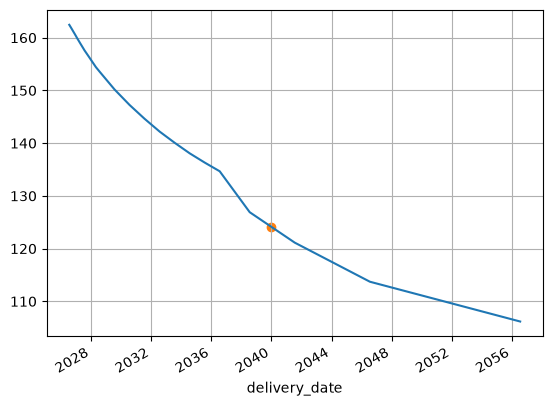

In [24]:
usd_calendar = ql.UnitedStates(ql.UnitedStates.Settlement)
jpy_calendar = ql.Japan()
calendar = ql.JointCalendar(
    usd_calendar,
    jpy_calendar,
    ql.JoinHolidays,
)

def to_py_date(date: ql.Date):
    return datetime(date.year(), date.month(), date.dayOfMonth())

def to_ql_date(date: datetime):
    return ql.Date(date.day, date.month, date.year)

def interp_fwd_rate(deal_date: datetime):
    delivery_date = to_py_date(calendar.advance(to_ql_date(deal_date), 2, ql.Days))
    target = pd.Timestamp(delivery_date).date()

    x = np.array([d.toordinal() for d in usdjpy_fwd["delivery_date"]], dtype=float)
    y = np.log(usdjpy_fwd["outright"].to_numpy(dtype=float))
    xt = float(delivery_date.toordinal())

    return float(np.exp(np.interp(xt, x, y)))

usdjpy_fwd.plot(x="delivery_date", y="outright", legend=None, grid=True)

dd = datetime(2040, 1, 1)
fwd_rate = interp_fwd_rate(dd)

plt.scatter([dd], [fwd_rate], c="C1")

plt.show()

PRDCのクーポンは（フロアとキャップを考えなければ）$c_f$と$c_d$を用いて次のように決められる
$$q = c_f {FX_t \over FX_0} - c_d$$
PVを評価するには$FX_t$にフォワード$F_t$を代入する
$$q = c_f {F_t \over FX_0} - c_d$$